<a href="https://colab.research.google.com/github/erinschaverien15/Bug-detection-and-classification/blob/main/Midterm_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Setup - Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Settings
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]

#Load data
from google.colab import drive
drive.mount('/content/drive')
Data_Path = "/content/drive/MyDrive/Mid-term project/Data/"
bug_data = pd.read_csv(Data_Path + "bug_dataset_with_priority_and_severity.csv")
bug_data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,priority,environment,developer_role,root_cause,suggested_fix,explanation,created_at
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in t...,403.0,API Bug,Mobile,Spring Boot,High,High,Development,Full-Stack Developer,Misconfiguration or logic issue related to api...,Review and fix the api bug according to best p...,This bug requires a full-stack developer due t...,07/04/2025
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Data,GCP,Medium,High,Production,Backend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a backend developer due to i...,04/07/2025
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bu...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Normal,Production,Mobile Developer,Misconfiguration or logic issue related to clo...,Review and fix the cloud configuration bug acc...,This bug requires a mobile developer due to it...,02/05/2025
3,BUG_000004,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Backend Systems,Flask,Medium,High,Production,Mobile Developer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a mobile developer due to it...,03/07/2025
4,BUG_000005,Logging Bug detected in system,This issue relates to a logging bug occurring ...,503.0,Logging Bug,Mobile,Flask,High,High,Staging,Backend Developer,Misconfiguration or logic issue related to log...,Review and fix the logging bug according to be...,This bug requires a backend developer due to i...,09/09/2025


Basic Statistics

In [ ]:
#Number of bugs
print("Number of bugs: ", len(bug_data))

#Number of errors per error_code
print("Number of errors per error_code: \n", bug_data["error_code"].value_counts())

#Number of errors per severity
print("Number of errors per severity: \n", bug_data["severity"].value_counts())

#Number of errors per priority rating
print("Number of errors per priority rating: \n", bug_data["priority"].value_counts())

#Number of errors per environment
print("Number of errors per environment: \n", bug_data["environment"].value_counts())

Number of bugs:  50000
Number of errors per error_code: 
 error_code
503.0    6421
404.0    6335
401.0    6279
502.0    6278
500.0    6254
403.0    6157
400.0    6088
Name: count, dtype: int64
Number of errors per severity: 
 severity
Low         12628
High        12535
Critical    12432
Medium      12405
Name: count, dtype: int64
Number of errors per priority rating: 
 priority
Urgent    17165
Low       15723
High      12435
Normal     4677
Name: count, dtype: int64
Number of errors per environment: 
 environment
Staging        16913
Development    16731
Production     16356
Name: count, dtype: int64


In [ ]:
#Replace string with int ratings
bug_data["severity"] = bug_data["severity"].replace({"Low": 1, "Medium": 2, "High": 3, "Critical": 4})
bug_data["priority"] = bug_data["priority"].replace({"Low": 1, "Normal": 2, "High": 3, "Urgent": 4})

#Priority by error code
print("Priority by error code: \n", bug_data.groupby("error_code")["priority"].median())

#Severity by environment
environment_severity = bug_data.groupby("environment")["severity"].agg
print("Severity by environment: \n", bug_data.groupby("environment")["severity"].median())

#Priority by environment
print("Priority by environment: \n", bug_data.groupby("environment")["priority"].median())

#Severity by bug domain
print("Severity by bug domain: \n", bug_data.groupby("bug_domain")["severity"].median())

#Priority by bug domain
print("Priority by bug domain: \n", bug_data.groupby("bug_domain")["priority"].median())

Severity by error code: 
 error_code
400.0    3.0
401.0    3.0
403.0    2.0
404.0    2.0
500.0    2.0
502.0    2.0
503.0    3.0
Name: severity, dtype: float64
Priority by error code: 
 error_code
400.0    3.0
401.0    3.0
403.0    3.0
404.0    3.0
500.0    3.0
502.0    3.0
503.0    3.0
Name: priority, dtype: float64
Severity by environment: 
 environment
Development    2.0
Production     2.0
Staging        3.0
Name: severity, dtype: float64
Priority by environment: 
 environment
Development    3.0
Production     3.0
Staging        3.0
Name: priority, dtype: float64
Severity by bug domain: 
 bug_domain
Backend Systems    3.0
Cloud              2.0
Data               2.0
DevOps             3.0
Mobile             2.0
Web Development    2.0
Name: severity, dtype: float64
Priority by bug domain: 
 bug_domain
Backend Systems    3.0
Cloud              3.0
Data               3.0
DevOps             3.0
Mobile             3.0
Web Development    3.0
Name: priority, dtype: float64


Visualisation

/tmp/ipykernel_4986/2893192053.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_by_domain.index, y=severity_by_domain.values, palette='viridis')


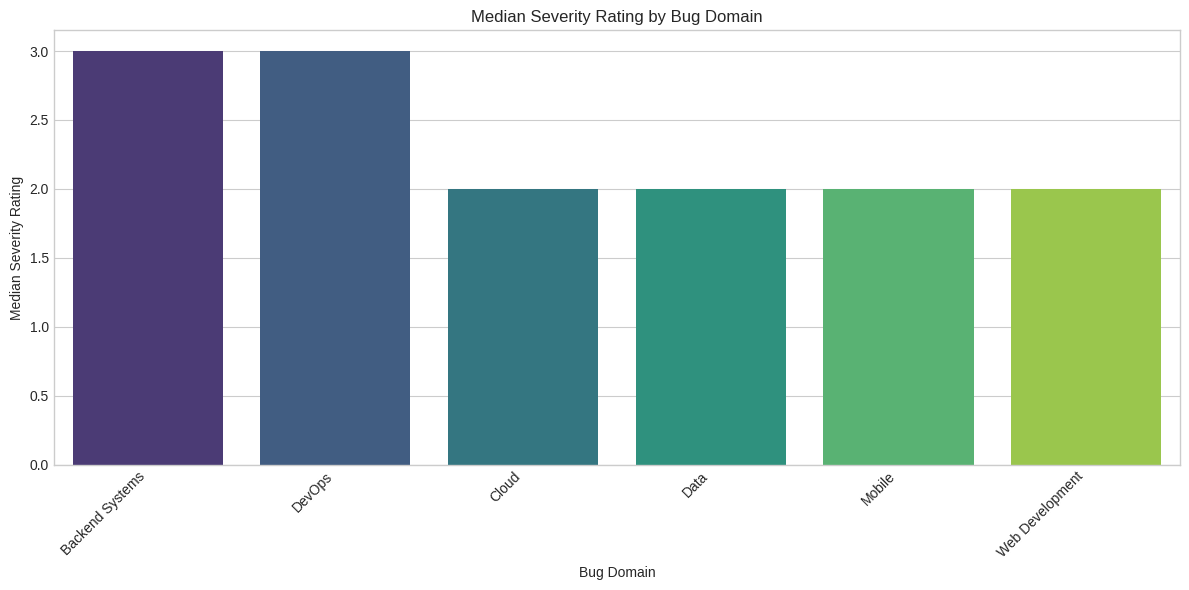

In [ ]:
#Bar Plot of Severity based on Bug Domain

severity_by_domain = bug_data.groupby("bug_domain")["severity"].median().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=severity_by_domain.index, y=severity_by_domain.values, palette='viridis')
plt.title('Median Severity Rating by Bug Domain')
plt.xlabel('Bug Domain')
plt.ylabel('Median Severity Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4986/2451041288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_by_environment.index, y=severity_by_environment.values, palette='viridis')


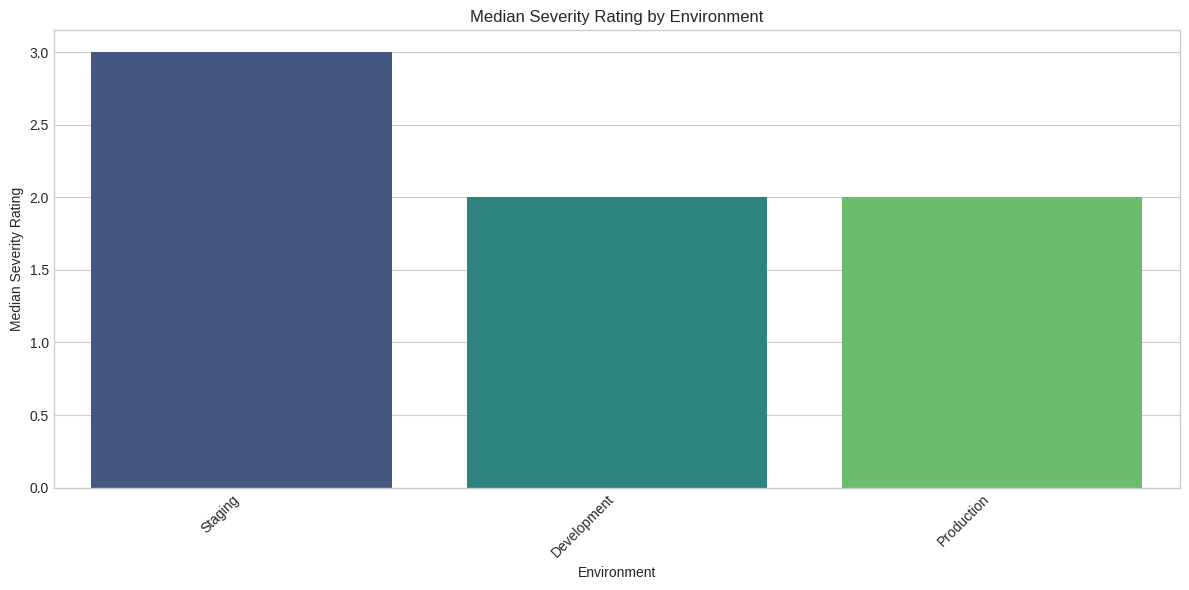

In [ ]:
#Bar Plot of Severity by environment

severity_by_environment = bug_data.groupby("environment")["severity"].median().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=severity_by_environment.index, y=severity_by_environment.values, palette='viridis')
plt.title('Median Severity Rating by Environment')
plt.xlabel('Environment')
plt.ylabel('Median Severity Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

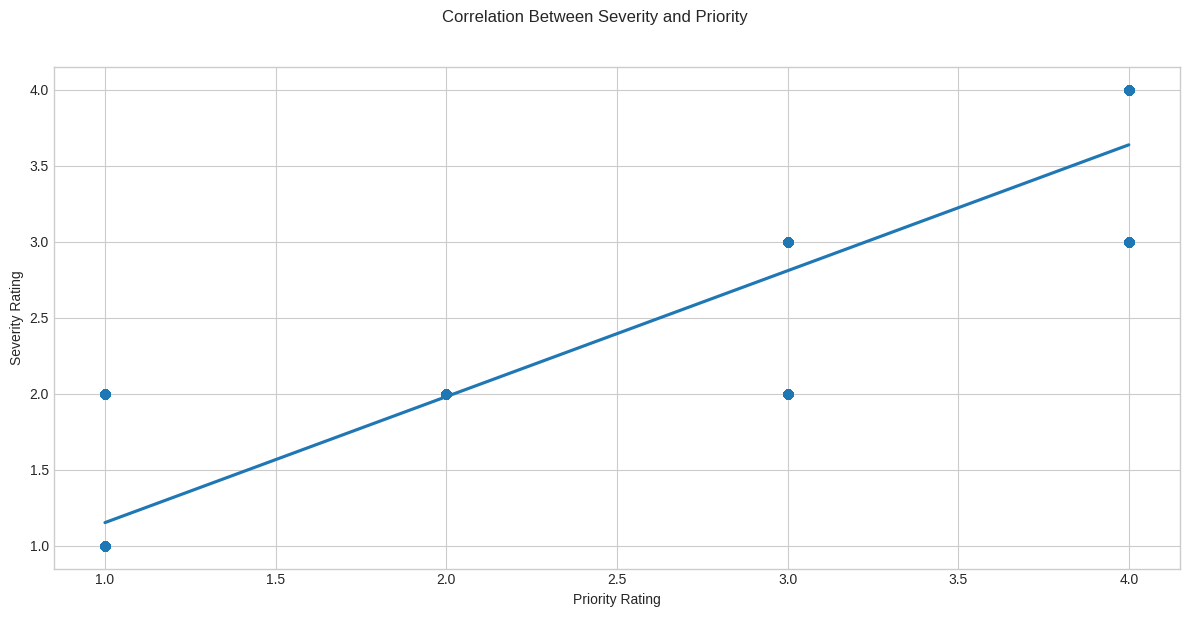

Correlation between priority and severity: 0.9219518208417036


In [ ]:
fig, ax = plt.subplots(figsize = (12, 6))
ax.scatter(bug_data["priority"], bug_data["severity"])
sns.regplot(x = bug_data['priority'], y = bug_data['severity'])
plt.suptitle('Correlation Between Severity and Priority', y=1.02)
plt.xlabel('Priority Rating')
plt.ylabel('Severity Rating')
plt.tight_layout()
plt.show()

correlation = bug_data['priority'].corr(bug_data['severity'])
print("Correlation between priority and severity:", correlation)